# Privacy-Aware Machine Learning with Opacus DP-SGD
Practical implementation of Differential Privacy in deep learning using the Opacus framework

## Introduction

In this demo, we'll learn how to train deep neural networks with **Differential Privacy (DP)** using the `Opacus` framework. We'll specifically explore:

1. **Baseline Training**: Standard non-private model training
2. **Privacy-Preserving Training**: Using DP-SGD (Differentially Private Stochastic Gradient Descent)
3. **Privacy Budget Tracking**: Monitoring epsilon (ε) and delta (δ) during training
4. **Privacy-Accuracy Trade-off**: Analyzing how privacy protection affects model performance

Key concepts:
- **DP-SGD**: Adds clipping and noise to gradients during training
- **Privacy Budget (ε)**: Measure of privacy loss - lower ε = stronger privacy
- **Gradient Clipping**: Bounds the influence of individual samples
- **Noise Addition**: Gaussian noise added to clipped gradients

## Setup and Imports

In [1]:
# Install required packages
!pip install -q opacus
!pip install -q torch torchvision
!pip install -q matplotlib seaborn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 4.9 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

✅ All imports successful!
PyTorch version: 2.10.0+cu128
Device: cuda


## Data Preparation and Visualization

In [ ]:
# Download and prepare CIFAR-10 dataset
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                        (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                        (0.2023, 0.1994, 0.2010))
])

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

print(f"✅ Dataset loaded!")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

100%|██████████| 170M/170M [00:27<00:00, 6.25MB/s]


✅ Dataset loaded!
Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
# Create data loaders
BATCH_SIZE = 64
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✅ Data loaders created!")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Test batches per epoch: {len(test_loader)}")

✅ Data loaders created!
Training batches per epoch: 782
Test batches per epoch: 157


## Define the Neural Network Model

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()
        self.max_pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.max_pool(x)
        x = self.relu(self.conv2(x))
        x = self.max_pool(x)
        x = self.relu(self.conv3(x))
        x = self.max_pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Create a model instance
model = SimpleCNN(num_classes=10)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model created!")
print(f"Total parameters: {total_params:,}")
print(model)

✅ Model created!
Total parameters: 545,098
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
)


## Part 1: Baseline Training (Non-Private Model)

In [ ]:
def train_epoch(model, train_loader, optimizer, criterion, device, max_grad_norm=None):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        # Statistics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def evaluate(model, test_loader, criterion, device):
    """Evaluate model on test set"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(test_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

print("✅ Training functions defined!")

✅ Training functions defined!


In [ ]:
# Baseline training (non-private)
print("=" * 60)
print("BASELINE TRAINING (Non-Private)")
print("=" * 60)

# Shared hyperparameters for fair baseline-vs-DP comparison
EPOCHS = 30
LEARNING_RATE = 0.03
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
MAX_GRAD_NORM = 1.0
LABEL_SMOOTHING = 0.1

print(
    f"Hyperparameters -> epochs: {EPOCHS}, lr: {LEARNING_RATE}, "
    f"momentum: {MOMENTUM}, weight_decay: {WEIGHT_DECAY}, "
    f"max_grad_norm: {MAX_GRAD_NORM}, label_smoothing: {LABEL_SMOOTHING}"
)

model_baseline = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.SGD(
    model_baseline.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=True,
 )

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

baseline_history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        model_baseline,
        train_loader,
        optimizer,
        criterion,
        device,
        max_grad_norm=MAX_GRAD_NORM,
    )
    test_loss, test_acc = evaluate(model_baseline, test_loader, criterion, device)
    scheduler.step()

    baseline_history['train_loss'].append(train_loss)
    baseline_history['train_acc'].append(train_acc)
    baseline_history['test_loss'].append(test_loss)
    baseline_history['test_acc'].append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

print("\n✅ Baseline training complete!")
print(f"Final Test Accuracy: {baseline_history['test_acc'][-1]:.2f}%")

BASELINE TRAINING (Non-Private)
Hyperparameters -> epochs: 5, lr: 0.02, momentum: 0.9, weight_decay: 0.0005
Epoch 1/5 | Train Loss: 1.5420 | Train Acc: 44.11% | Test Loss: 1.1717 | Test Acc: 58.78%
Epoch 2/5 | Train Loss: 1.1794 | Train Acc: 58.03% | Test Loss: 0.9979 | Test Acc: 65.63%
Epoch 3/5 | Train Loss: 0.9914 | Train Acc: 65.33% | Test Loss: 0.9343 | Test Acc: 67.14%
Epoch 4/5 | Train Loss: 0.8163 | Train Acc: 71.22% | Test Loss: 0.8199 | Test Acc: 71.46%
Epoch 5/5 | Train Loss: 0.6831 | Train Acc: 75.88% | Test Loss: 0.7754 | Test Acc: 73.28%

✅ Baseline training complete!
Final Test Accuracy: 73.28%


## Part 2: Privacy-Preserving Training with DP-SGD

In this section, we'll implement the same model but with Differential Privacy using Opacus.

Key parameters:
- **max_grad_norm**: Maximum L2 norm of per-sample gradients (gradient clipping)
- **noise_multiplier**: Parameter controlling noise scale σ = noise_multiplier × max_grad_norm
- **target_epsilon**: Target privacy budget ε
- **target_delta**: Target δ (typically set to 1/N where N is dataset size)

In [8]:
def train_epoch_private(model, train_loader, optimizer, criterion, device, privacy_engine=None, delta=None):
    """Train for one epoch with privacy"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    epsilon_list = []

    if privacy_engine is not None and delta is None:
        if 'DELTA' in globals():
            delta = DELTA
        else:
            raise RuntimeError("DELTA is not defined. Run the privacy configuration cell first.")

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        # Track epsilon (if using privacy engine)
        if privacy_engine is not None:
            epsilon = privacy_engine.accountant.get_epsilon(delta=delta)
            epsilon_list.append(epsilon)

    avg_loss = total_loss / len(train_loader)
    accuracy = 100.0 * correct / total
    final_epsilon = epsilon_list[-1] if epsilon_list else 0.0

    return avg_loss, accuracy, final_epsilon

print("✅ Private training function defined!")

✅ Private training function defined!


In [ ]:
# Privacy configurations and private training runs
DELTA = 1 / len(train_dataset)  # δ = 1/N
TARGET_EPSILON_VALUES = [10.0, 5.0, 2.0, 1.0, 0.5]

# Reuse baseline setup so baseline-vs-DP comparison is fair
if 'EPOCHS' not in globals():
    EPOCHS = 30
if 'LEARNING_RATE' not in globals():
    LEARNING_RATE = 0.03
if 'MOMENTUM' not in globals():
    MOMENTUM = 0.9
if 'WEIGHT_DECAY' not in globals():
    WEIGHT_DECAY = 5e-4
if 'MAX_GRAD_NORM' not in globals():
    MAX_GRAD_NORM = 1.0
if 'LABEL_SMOOTHING' not in globals():
    LABEL_SMOOTHING = 0.1

print(f"Dataset size N: {len(train_dataset)}")
print(f"Delta (δ): {DELTA:.8f}")
print(f"Target epsilon values: {TARGET_EPSILON_VALUES}")
print(
    f"Shared optimizer -> epochs: {EPOCHS}, lr: {LEARNING_RATE}, "
    f"momentum: {MOMENTUM}, weight_decay: {WEIGHT_DECAY}, "
    f"max_grad_norm: {MAX_GRAD_NORM}, label_smoothing: {LABEL_SMOOTHING}"
)
print()

private_models = {}
privacy_histories = {}

for target_eps in TARGET_EPSILON_VALUES:
    print("=" * 60)
    print(f"PRIVATE TRAINING with target ε = {target_eps}")
    print("=" * 60)

    model_private = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = optim.SGD(
        model_private.parameters(),
        lr=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY,
        nesterov=True,
    )

    privacy_engine = PrivacyEngine()
    model_private, optimizer, train_loader_private = privacy_engine.make_private_with_epsilon(
        module=model_private,
        optimizer=optimizer,
        data_loader=train_loader,
        target_delta=DELTA,
        target_epsilon=target_eps,
        epochs=EPOCHS,
        max_grad_norm=MAX_GRAD_NORM,
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'epsilon': [],
    }

    for epoch in range(EPOCHS):
        train_loss, train_acc, epsilon = train_epoch_private(
            model_private,
            train_loader_private,
            optimizer,
            criterion,
            device,
            privacy_engine,
            delta=DELTA,
        )
        test_loss, test_acc = evaluate(model_private, test_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['epsilon'].append(epsilon)

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | ε: {epsilon:.4f}"
        )

    private_models[target_eps] = model_private
    privacy_histories[target_eps] = history
    print(f"Completed target ε = {target_eps}\n")

Dataset size N: 50000
Delta (δ): 0.00002000
Target epsilon values: [10.0, 5.0, 2.0, 1.0, 0.5]
Shared optimizer -> epochs: 5, lr: 0.02, momentum: 0.9, weight_decay: 0.0005

PRIVATE TRAINING with target ε = 10.0
Epoch 1/5 | Train Loss: 1.9935 | Train Acc: 28.71% | Test Acc: 40.03% | ε: 6.6311
Epoch 2/5 | Train Loss: 1.8515 | Train Acc: 36.73% | Test Acc: 43.04% | ε: 7.7412
Epoch 3/5 | Train Loss: 1.8116 | Train Acc: 40.36% | Test Acc: 46.02% | ε: 8.6046
Epoch 4/5 | Train Loss: 1.7870 | Train Acc: 42.06% | Test Acc: 46.71% | ε: 9.3405
Epoch 5/5 | Train Loss: 1.7606 | Train Acc: 42.47% | Test Acc: 47.20% | ε: 9.9964
Completed target ε = 10.0

PRIVATE TRAINING with target ε = 5.0
Epoch 1/5 | Train Loss: 1.9826 | Train Acc: 29.20% | Test Acc: 39.96% | ε: 3.5739
Epoch 2/5 | Train Loss: 1.8490 | Train Acc: 37.05% | Test Acc: 42.41% | ε: 4.0698
Epoch 3/5 | Train Loss: 1.8458 | Train Acc: 39.07% | Test Acc: 45.48% | ε: 4.4293
Epoch 4/5 | Train Loss: 1.8212 | Train Acc: 41.42% | Test Acc: 47.34% 

## Part 3: Results Analysis and Visualization

In [10]:
# Prepare comparison data
if 'baseline_history' not in globals() or 'privacy_histories' not in globals():
    raise RuntimeError("Please run baseline and private training cells first.")

comparison_data = []

# Baseline results
comparison_data.append({
    'epsilon': 'Baseline',
    'train_acc': baseline_history['train_acc'][-1],
    'test_acc': baseline_history['test_acc'][-1],
    'train_loss': baseline_history['train_loss'][-1],
    'test_loss': baseline_history['test_loss'][-1],
})

# Prefer explicit target list if available, otherwise derive from trained histories
if 'TARGET_EPSILON_VALUES' in globals():
    epsilon_values = [eps for eps in TARGET_EPSILON_VALUES if eps in privacy_histories]
else:
    epsilon_values = sorted(list(privacy_histories.keys()), reverse=True)

# Private models results
for eps in epsilon_values:
    history = privacy_histories[eps]
    comparison_data.append({
        'epsilon': eps,
        'train_acc': history['train_acc'][-1],
        'test_acc': history['test_acc'][-1],
        'train_loss': history['train_loss'][-1],
        'test_loss': history['test_loss'][-1],
    })

comparison_df = pd.DataFrame(comparison_data)
print("=" * 80)
print("COMPARISON TABLE: Baseline vs. Privacy-Preserving Models")
print("=" * 80)
print(comparison_df.to_string(index=False))
print()

COMPARISON TABLE: Baseline vs. Privacy-Preserving Models
 epsilon  train_acc  test_acc  train_loss  test_loss
Baseline  75.880000     73.28    0.683069   0.775362
    10.0  42.466934     47.20    1.760586   1.531956
     5.0  41.740136     47.77    1.783841   1.528953
     2.0  40.302156     46.70    1.849581   1.564165
     1.0  38.056486     44.48    1.879960   1.600289
     0.5  35.376402     42.86    1.971452   1.647769



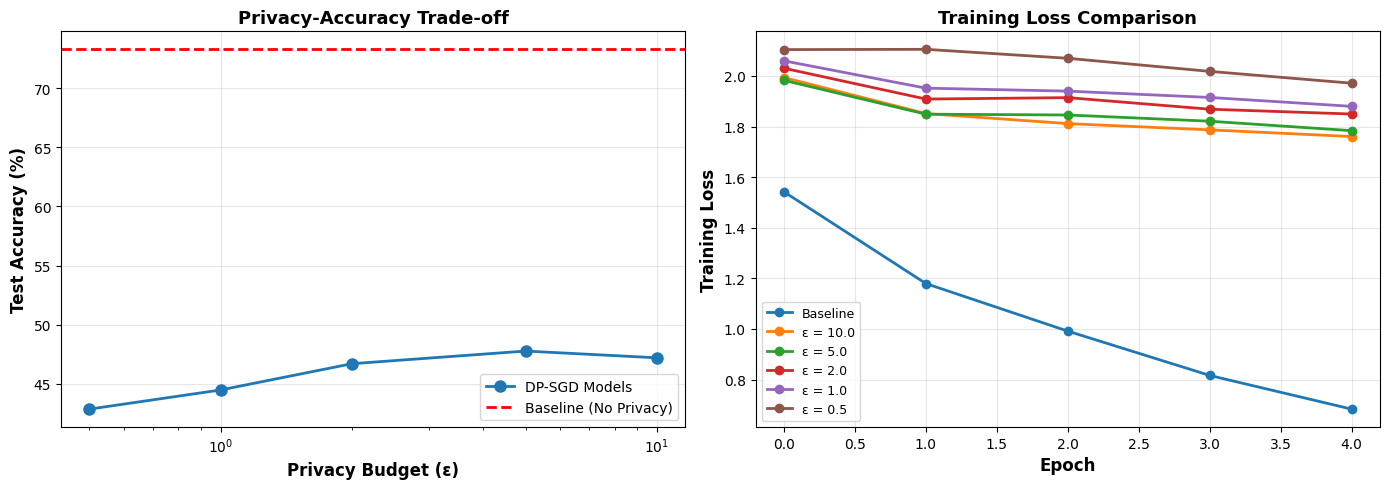

✅ Plot saved as 'privacy_accuracy_tradeoff.png'


In [11]:
# Plot 1: Clean Privacy-Accuracy Trade-off Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

private_eps = comparison_df[comparison_df['epsilon'] != 'Baseline']['epsilon'].tolist()

# Curve 1: Test Accuracy vs Epsilon
eps_values = private_eps + [100]  # Add baseline reference
acc_values = comparison_df[comparison_df['epsilon'] != 'Baseline']['test_acc'].tolist() + [
    comparison_df[comparison_df['epsilon'] == 'Baseline']['test_acc'].values[0]
]

axes[0].plot(eps_values[:-1], acc_values[:-1], 'o-', linewidth=2, markersize=8, label='DP-SGD Models')
axes[0].axhline(y=acc_values[-1], color='red', linestyle='--', linewidth=2, label='Baseline (No Privacy)')
axes[0].set_xlabel('Privacy Budget (ε)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Privacy-Accuracy Trade-off', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_xscale('log')

# Curve 2: Training Loss Curves Comparison
axes[1].plot(baseline_history['train_loss'], 'o-', label='Baseline', linewidth=2, markersize=6)
for eps in sorted(private_eps, reverse=True):
    axes[1].plot(privacy_histories[eps]['train_loss'], 'o-', label=f'ε = {eps}', linewidth=2, markersize=6)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Training Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Training Loss Comparison', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('privacy_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved as 'privacy_accuracy_tradeoff.png'")

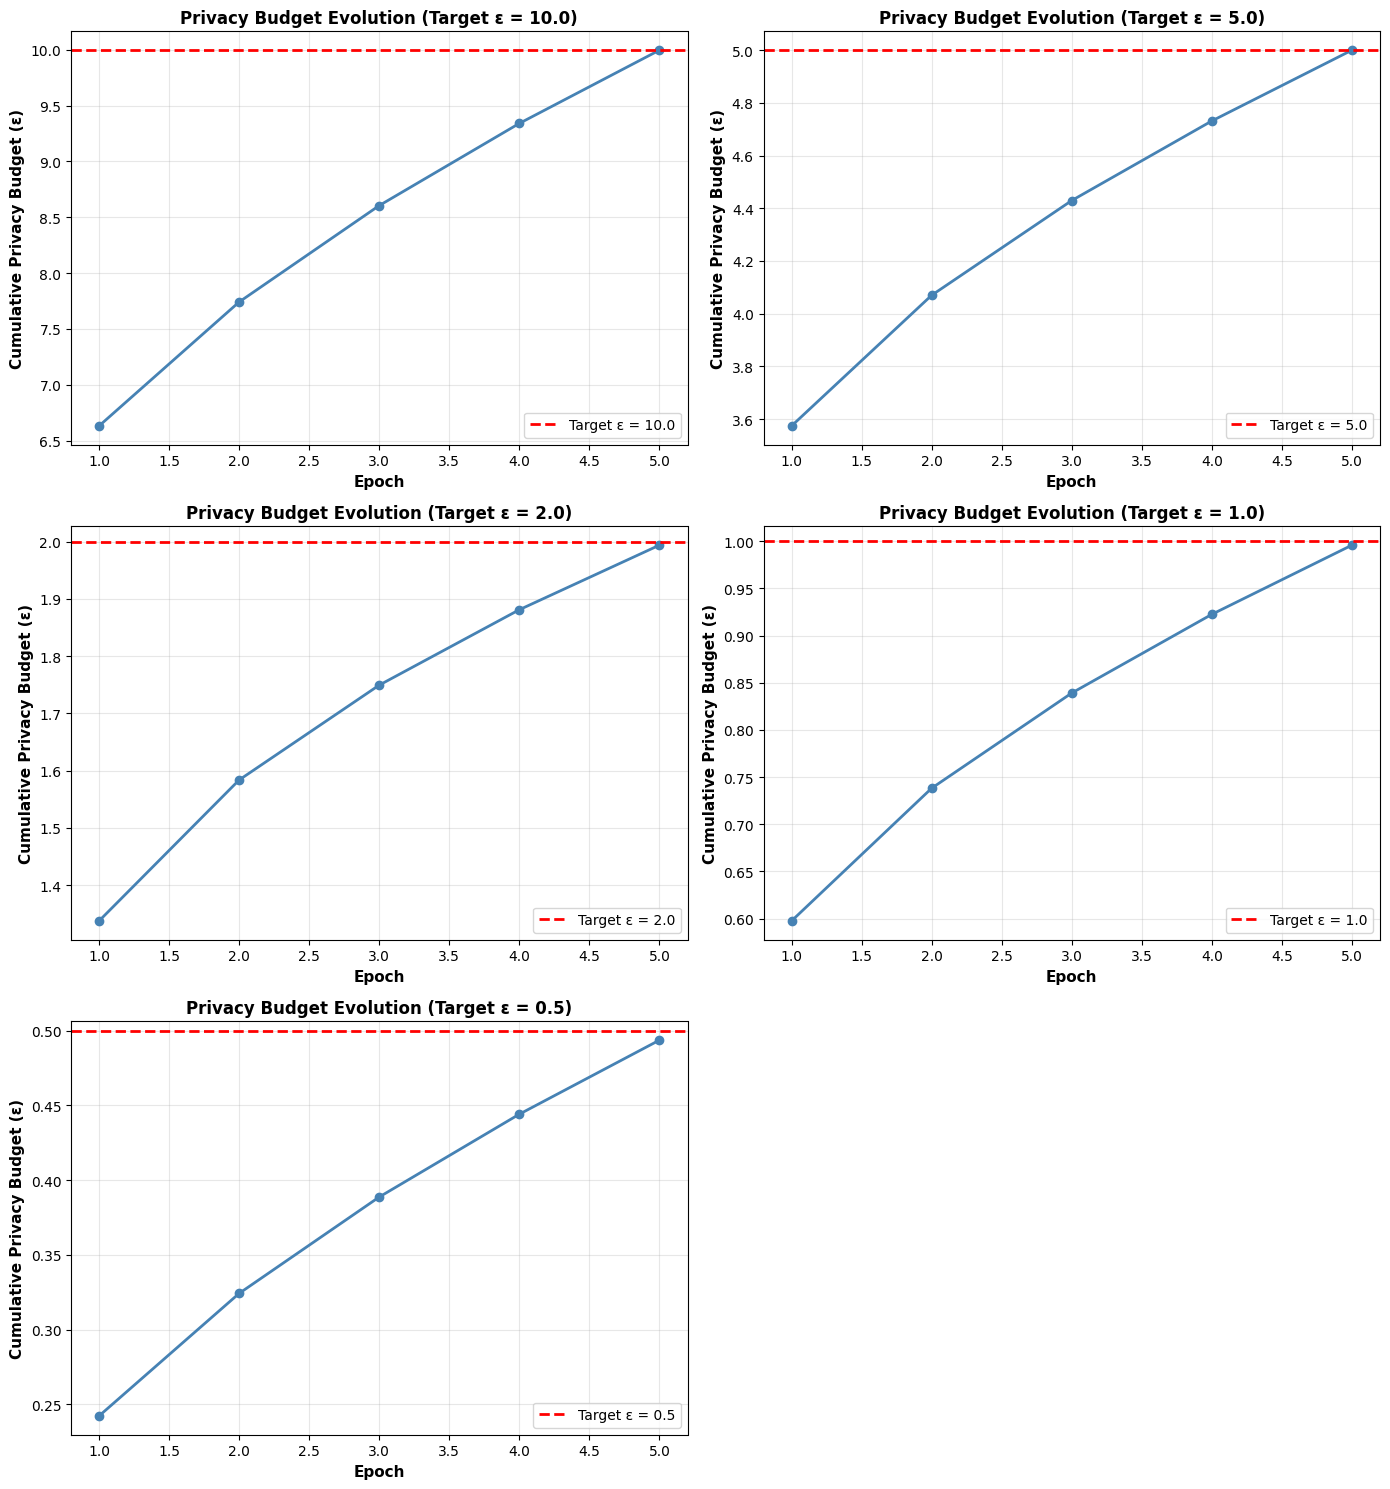

✅ Plot saved as 'epsilon_evolution.png'


In [12]:
# Plot 2: Privacy Budget (Epsilon) Evolution During Training
private_eps = comparison_df[comparison_df['epsilon'] != 'Baseline']['epsilon'].tolist()
num_eps = len(private_eps)

ncols = 2
nrows = int(np.ceil(num_eps / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.array(axes).reshape(-1)

for idx, eps in enumerate(private_eps):
    ax = axes[idx]
    epochs = list(range(1, len(privacy_histories[eps]['epsilon']) + 1))
    ax.plot(epochs, privacy_histories[eps]['epsilon'], 'o-', linewidth=2, markersize=6, color='steelblue')
    ax.axhline(y=eps, color='red', linestyle='--', linewidth=2, label=f'Target ε = {eps}')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Cumulative Privacy Budget (ε)', fontsize=11, fontweight='bold')
    ax.set_title(f'Privacy Budget Evolution (Target ε = {eps})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

# Hide unused subplot axes
for idx in range(num_eps, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('epsilon_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved as 'epsilon_evolution.png'")

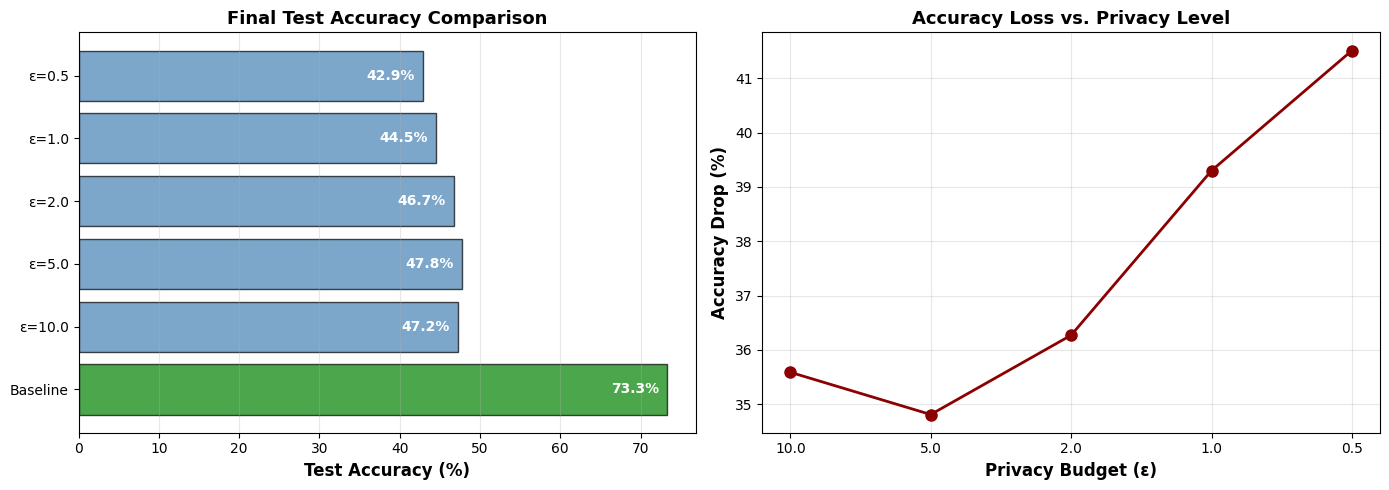

✅ Plot saved as 'accuracy_comparison.png'


In [13]:
# Plot 3: Model Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

private_eps = comparison_df[comparison_df['epsilon'] != 'Baseline']['epsilon'].tolist()

# Test accuracy bar chart
models = ['Baseline'] + [f'ε={eps}' for eps in private_eps]
test_accs = comparison_df['test_acc'].tolist()
colors = ['green'] + ['steelblue'] * len(private_eps)

axes[0].barh(models, test_accs, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Final Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(test_accs):
    axes[0].text(v - 1, i, f'{v:.1f}%', va='center', ha='right', fontweight='bold', color='white')

# Accuracy drop percentage
baseline_acc = comparison_df[comparison_df['epsilon'] == 'Baseline']['test_acc'].values[0]
accuracy_drops = []
for eps in private_eps:
    acc = comparison_df[comparison_df['epsilon'] == eps]['test_acc'].values[0]
    drop_pct = ((baseline_acc - acc) / baseline_acc) * 100
    accuracy_drops.append(drop_pct)

eps_labels = [f'{eps}' for eps in private_eps]
axes[1].plot(eps_labels, accuracy_drops, 'o-', linewidth=2, markersize=8, color='darkred')
axes[1].set_xlabel('Privacy Budget (ε)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy Drop (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Accuracy Loss vs. Privacy Level', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved as 'accuracy_comparison.png'")

In [14]:
# Detailed Analysis
print("=" * 80)
print("DETAILED ANALYSIS: Privacy-Accuracy Trade-off")
print("=" * 80)
print()

private_eps = comparison_df[comparison_df['epsilon'] != 'Baseline']['epsilon'].tolist()
baseline_acc = comparison_df[comparison_df['epsilon'] == 'Baseline']['test_acc'].values[0]
print(f"Baseline (Non-Private) Test Accuracy: {baseline_acc:.2f}%")
print()

print("Privacy-Preserving Models:")
print("-" * 80)
for eps in private_eps:
    row = comparison_df[comparison_df['epsilon'] == eps].iloc[0]
    drop = ((baseline_acc - row['test_acc']) / baseline_acc) * 100
    print(
        f"ε = {float(eps):4.1f} | Test Acc: {row['test_acc']:5.2f}% | "
        f"Accuracy Drop: {drop:5.2f}% | Loss: {row['test_loss']:.4f}"
    )

print()
print("KEY INSIGHTS:")
print("-" * 80)

# Find best privacy-accuracy trade-off
best_eps = private_eps[0]
best_acc = comparison_df[comparison_df['epsilon'] == best_eps]['test_acc'].values[0]

for eps in private_eps:
    acc = comparison_df[comparison_df['epsilon'] == eps]['test_acc'].values[0]
    if acc > best_acc:
        best_eps = eps
        best_acc = acc

strongest_privacy_eps = min(private_eps)
weakest_privacy_eps = max(private_eps)

print(
    f"1. Strongest Privacy (ε = {strongest_privacy_eps}): "
    f"Accuracy = {comparison_df[comparison_df['epsilon'] == strongest_privacy_eps]['test_acc'].values[0]:.2f}%"
)
print(
    f"2. Weakest Privacy (ε = {weakest_privacy_eps}): "
    f"Accuracy = {comparison_df[comparison_df['epsilon'] == weakest_privacy_eps]['test_acc'].values[0]:.2f}%"
)
print(f"3. Best Privacy-Accuracy Balance: ε = {best_eps}, Accuracy = {best_acc:.2f}%")
print()
print(
    f"Accuracy loss with strong privacy (ε = {strongest_privacy_eps}): "
    f"{((baseline_acc - comparison_df[comparison_df['epsilon'] == strongest_privacy_eps]['test_acc'].values[0]) / baseline_acc) * 100:.2f}%"
)
print()

DETAILED ANALYSIS: Privacy-Accuracy Trade-off

Baseline (Non-Private) Test Accuracy: 73.28%

Privacy-Preserving Models:
--------------------------------------------------------------------------------
ε = 10.0 | Test Acc: 47.20% | Accuracy Drop: 35.59% | Loss: 1.5320
ε =  5.0 | Test Acc: 47.77% | Accuracy Drop: 34.81% | Loss: 1.5290
ε =  2.0 | Test Acc: 46.70% | Accuracy Drop: 36.27% | Loss: 1.5642
ε =  1.0 | Test Acc: 44.48% | Accuracy Drop: 39.30% | Loss: 1.6003
ε =  0.5 | Test Acc: 42.86% | Accuracy Drop: 41.51% | Loss: 1.6478

KEY INSIGHTS:
--------------------------------------------------------------------------------
1. Strongest Privacy (ε = 0.5): Accuracy = 42.86%
2. Weakest Privacy (ε = 10.0): Accuracy = 47.20%
3. Best Privacy-Accuracy Balance: ε = 5.0, Accuracy = 47.77%

Accuracy loss with strong privacy (ε = 0.5): 41.51%



## Part 4: Key Takeaways and Conclusions

### What is Differential Privacy?
Differential Privacy (DP) provides a mathematical guarantee that the presence or absence of any individual's data in a dataset has minimal impact on the output of a machine learning algorithm.

### How DP-SGD Works
1. **Gradient Clipping**: Limits the maximum contribution of each sample's gradient
2. **Noise Addition**: Adds Gaussian noise to the clipped gradients
3. **Privacy Accounting**: Tracks cumulative privacy loss (ε) across iterations
4. **Privacy Budget**: Controls the trade-off between privacy and model utility

### Privacy Budget (ε) Interpretation
- **ε < 0.5**: Very strong privacy protection (high privacy guarantee)
- **ε = 1.0 - 3.0**: Strong privacy protection
- **ε = 5.0 - 10.0**: Moderate privacy protection
- **ε > 10.0**: Weaker privacy protection (closer to non-private)

### Practical Recommendations
1. **For Sensitive Data**: Use ε < 1.0 (e.g., healthcare, financial)
2. **For General Applications**: Use ε between 1.0 - 5.0
3. **Monitor Trade-offs**: Balance privacy budget against model accuracy requirements
4. **Hyperparameter Tuning**: Adjust gradient norm, noise multiplier, and batch size
5. **Iterative Approach**: Start with weak privacy and gradually increase protection

### Limitations and Considerations
- Privacy comes at a computational cost
- Model accuracy typically decreases with stronger privacy
- Larger datasets allow stronger privacy with less accuracy loss
- Privacy budget is cumulative across all training iterations


## Part 5: Advanced Exploration - Hyperparameter Impact

In this section, we explore how different DP-SGD hyperparameters affect privacy and accuracy.


In [15]:
print("=" * 80)
print("ADVANCED EXPLORATION: Further Investigation Directions")
print("=" * 80)
print()

print("Hyperparameters to Experiment With:")
print("-" * 80)
print("""
1. **Gradient Clipping Norm** (max_grad_norm)
   - Lower values: Stronger privacy, but may hurt convergence
   - Higher values: Weaker privacy, but better gradient signal
   - Typical range: 0.5 - 2.0

2. **Noise Multiplier** (noise_multiplier)
   - Controls the scale of Gaussian noise σ = noise_multiplier × max_grad_norm
   - Higher values: Stronger privacy, lower accuracy
   - Lower values: Weaker privacy, higher accuracy

3. **Batch Size**
   - Larger batches: Better gradient estimates, but more privacy loss per step
   - Smaller batches: More noisy gradients, less privacy loss per step

4. **Learning Rate**
   - Must often be reduced with DP-SGD due to gradient noise
   - Typical DP-SGD learning rates: 0.01 - 0.1

5. **Training Epochs**
   - More epochs increase privacy loss (ε grows with iterations)
   - Trade-off: More training = better accuracy but worse privacy
""")

print()
print("Suggested Next Experiments:")
print("-" * 80)
print("""
1. Vary max_grad_norm: [0.1, 0.5, 1.0, 2.0, 5.0]
2. Compare different architectures (ResNet, MobileNet)
3. Test on larger datasets (CIFAR-100, ImageNet)
4. Implement early stopping to preserve privacy budget
5. Compare with other privacy mechanisms (DP-SGD vs PATE)
6. Analyze privacy amplification by sampling
""")

print()
print("📚 Resources:")
print("-" * 80)
print("""
- Opacus Documentation: https://opacus.ai/
- DP-SGD Paper: https://arxiv.org/abs/1607.00133
- Differential Privacy Explained: https://github.com/tensorflow/privacy
- PyTorch Privacy Tutorials: https://pytorch.org/
""")

print()
print("✅ Demo Complete!")


ADVANCED EXPLORATION: Further Investigation Directions

Hyperparameters to Experiment With:
--------------------------------------------------------------------------------

1. **Gradient Clipping Norm** (max_grad_norm)
   - Lower values: Stronger privacy, but may hurt convergence
   - Higher values: Weaker privacy, but better gradient signal
   - Typical range: 0.5 - 2.0

2. **Noise Multiplier** (noise_multiplier)
   - Controls the scale of Gaussian noise σ = noise_multiplier × max_grad_norm
   - Higher values: Stronger privacy, lower accuracy
   - Lower values: Weaker privacy, higher accuracy

3. **Batch Size**
   - Larger batches: Better gradient estimates, but more privacy loss per step
   - Smaller batches: More noisy gradients, less privacy loss per step

4. **Learning Rate**
   - Must often be reduced with DP-SGD due to gradient noise
   - Typical DP-SGD learning rates: 0.01 - 0.1

5. **Training Epochs**
   - More epochs increase privacy loss (ε grows with iterations)
   - Trade